In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)
    
def l2_penalty(w):
    return (w ** 2).sum() / 2

class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()

    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))
        

In [2]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))

## Q1

Found that under certain range of $lamda$, as $lambda$ increases, the train loss asc and val loss dsc.

Fun fact: when lr and $lambda$ are too large, the loss will explode.

> Simple explanation:
>
> Assume $L(w) = \frac{\lambda}{2} w^2$, then grad $\nabla L(w) = \lambda w$.
>
> Apply the gradient descent, we have $w_{t+1} = w_t - \eta \nabla L(w) = (1-\eta\lambda)w_t$.
>
> So considering the abs value, we find when $|1-\eta\lambda| > 1$, the training loss diverges.

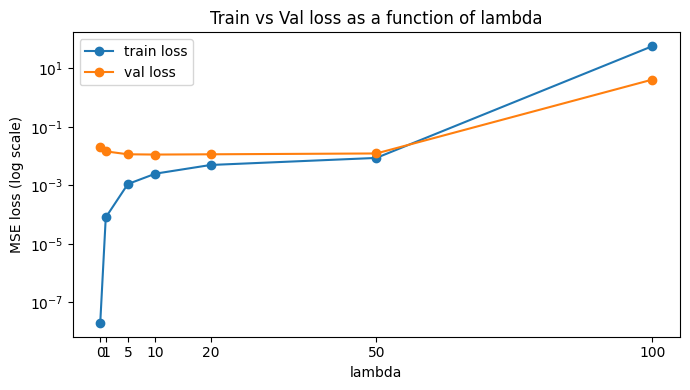

In [3]:
import matplotlib.pyplot as plt

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.019)
    model.board.display = False
    t = d2l.Trainer(max_epochs=10)
    t.fit(model, data)
    # print(f'lambd={lambd:>6.1f}  L2 norm of w: {float(l2_penalty(model.w)):.4f}')
    return model

lambdas = [0, 1, 5, 10, 20, 50, 100]
train_losses, val_losses = [], []

def mse(y_hat, y):
    return ((y_hat - y) ** 2 / 2).mean()

for lambd in lambdas:
    model = train_scratch(lambd)
    with torch.no_grad():
        train_losses.append(float(mse(model(data.X[:data.num_train]), data.y[:data.num_train])))
        val_losses.append(float(mse(model(data.X[data.num_train:]),   data.y[data.num_train:])))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambdas, train_losses, 'o-', label='train loss')
ax.plot(lambdas, val_losses,   'o-', label='val loss')
ax.set_yscale('log')
ax.set_xlabel('lambda')
ax.set_ylabel('MSE loss (log scale)')
ax.set_xticks(lambdas)
ax.legend()
ax.set_title('Train vs Val loss as a function of lambda')
plt.tight_layout()
plt.show()

## Q4

Frobenius norm $\|W\|_F^2 = \sum_{i=1}^m\sum_{j=1}^n W_{ij}^2 =\mathrm{tr}(W^\top W)$

## Q5

Dropout, early stop, noise injection...

## Q6

Consider negative log:

$$
P(w\mid x) = -\log P(x\mid w)-\log P(w)+C,
$$

which is aligned with:

$$
\text{loss}
=
\text{data fitting loss}
+
\text{regularization}
$$